<a href="https://colab.research.google.com/github/HarshiniThanish/DATA_SCIENCE-PROJECT/blob/main/DS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
cols = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

df = pd.read_csv(
    "heart.csv",
    header=None,
    names=cols
)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1,52,1,0,125,212,0,1,168,0,1,2,2,3,0
2,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
3,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
4,61,1,0,148,203,0,1,161,0,0,2,1,3,0


In [ ]:
df.shape

(1026, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1026 entries, 0 to 1025
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       1026 non-null   object
 1   sex       1026 non-null   object
 2   cp        1026 non-null   object
 3   trestbps  1026 non-null   object
 4   chol      1026 non-null   object
 5   fbs       1026 non-null   object
 6   restecg   1026 non-null   object
 7   thalach   1026 non-null   object
 8   exang     1026 non-null   object
 9   oldpeak   1026 non-null   object
 10  slope     1026 non-null   object
 11  ca        1026 non-null   object
 12  thal      1026 non-null   object
 13  target    1026 non-null   object
dtypes: object(14)
memory usage: 112.3+ KB


In [ ]:
df.isin(['?']).sum()


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1026,1026,1026,1026,1026,1026,1026,1026,1026,1026,1026,1026,1026,1026
unique,42,3,5,50,153,3,4,92,3,41,4,6,5,3
top,58,1,0,120,204,0,1,162,0,0,1,0,2,1
freq,68,713,497,128,21,872,513,35,680,329,482,578,544,526


In [ ]:
import os

os.makedirs("raw", exist_ok=True)
os.makedirs("gold", exist_ok=True)

print("Folders Created")

Folders Created


In [ ]:
import pandas as pd
import shutil

# Copy original file to raw folder
shutil.copy("heart.csv", "raw/heart.csv")

# Load dataset
df = pd.read_csv("raw/heart.csv")

print("Dataset Loaded")
print("Shape:", df.shape)

df.head()

Dataset Loaded
Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
print("="*50)
print("DATASET INFORMATION")
print("="*50)

print("\nInfo:")
print(df.info())

print("\nDescribe:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

DATASET INFORMATION

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

Describe:
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.69

In [ ]:
before = len(df)

df = df.drop_duplicates()

after = len(df)

print("Duplicates Removed:", before - after)

Duplicates Removed: 723


In [ ]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

In [ ]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [ ]:
print(df.dtypes)

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [ ]:
print("="*50)
print("VALIDATION")
print("="*50)

print("Missing Values:")
print(df.isnull().sum().sum())

print("Duplicates:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

print("\nFinal Shape:")
print(df.shape)

VALIDATION
Missing Values:
0
Duplicates:
0

Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Final Shape:
(302, 14)


In [ ]:
print("Age Range:")
print(df["age"].min(), "-", df["age"].max())

print("Cholesterol Range:")
print(df["chol"].min(), "-", df["chol"].max())

print("Target Values:")
print(df["target"].unique())

Age Range:
29 - 77
Cholesterol Range:
126 - 564
Target Values:
[0 1]


In [ ]:
df.to_csv("gold/clean_data.csv", index=False)

print("Clean dataset saved")
print("Location: gold/clean_data.csv")

Clean dataset saved
Location: gold/clean_data.csv


In [ ]:
print("="*50)
print("ETL PIPELINE COMPLETE")
print("="*50)

print("Original Shape:", (1025,14))
print("Final Shape:", df.shape)

print("Missing Values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())

print("Output File: gold/clean_data.csv")

ETL PIPELINE COMPLETE
Original Shape: (1025, 14)
Final Shape: (302, 14)
Missing Values: 0
Duplicates: 0
Output File: gold/clean_data.csv


In [ ]:
print(df.shape)
print(df.duplicated().sum())
print(df.isnull().sum().sum())

(302, 14)
0
0


Database schema

In [ ]:
import sqlite3

# Create database
conn = sqlite3.connect("heart_disease.db")

cursor = conn.cursor()

# Patient Table
cursor.execute("""
CREATE TABLE IF NOT EXISTS Patient (
    patient_id INTEGER PRIMARY KEY AUTOINCREMENT,
    age INTEGER NOT NULL CHECK(age BETWEEN 20 AND 100),
    sex INTEGER NOT NULL CHECK(sex IN (0,1))
);
""")

# ClinicalMeasurements Table
cursor.execute("""
CREATE TABLE IF NOT EXISTS ClinicalMeasurements (
    measurement_id INTEGER PRIMARY KEY AUTOINCREMENT,
    patient_id INTEGER NOT NULL,
    trestbps INTEGER CHECK(trestbps > 0),
    chol INTEGER CHECK(chol > 0),
    fbs INTEGER CHECK(fbs IN (0,1)),
    thalach INTEGER CHECK(thalach > 0),
    FOREIGN KEY(patient_id) REFERENCES Patient(patient_id)
);
""")

# ECGResults Table
cursor.execute("""
CREATE TABLE IF NOT EXISTS ECGResults (
    ecg_id INTEGER PRIMARY KEY AUTOINCREMENT,
    patient_id INTEGER NOT NULL,
    restecg INTEGER,
    exang INTEGER CHECK(exang IN (0,1)),
    oldpeak REAL,
    slope INTEGER,
    FOREIGN KEY(patient_id) REFERENCES Patient(patient_id)
);
""")

# Diagnosis Table
cursor.execute("""
CREATE TABLE IF NOT EXISTS HeartDiseaseDiagnosis (
    diagnosis_id INTEGER PRIMARY KEY AUTOINCREMENT,
    patient_id INTEGER NOT NULL,
    cp INTEGER,
    ca INTEGER,
    thal INTEGER,
    target INTEGER CHECK(target IN (0,1)),
    FOREIGN KEY(patient_id) REFERENCES Patient(patient_id)
);
""")

conn.commit()

print("Database and tables created successfully!")

Database and tables created successfully!


In [ ]:
cursor.execute("""
SELECT name
FROM sqlite_master
WHERE type='table';
""")

print(cursor.fetchall())

[('Patient',), ('sqlite_sequence',), ('ClinicalMeasurements',), ('ECGResults',), ('HeartDiseaseDiagnosis',)]


In [ ]:
import pandas as pd
import sqlite3

df = pd.read_csv("gold/clean_data.csv")

conn = sqlite3.connect("heart_disease.db")
cursor = conn.cursor()

print(df.shape)

(302, 14)


In [ ]:
for _, row in df.iterrows():

    # Insert into Patient
    cursor.execute("""
    INSERT INTO Patient(age, sex)
    VALUES (?, ?)
    """, (
        int(row['age']),
        int(row['sex'])
    ))

    patient_id = cursor.lastrowid

    # Insert into ClinicalMeasurements
    cursor.execute("""
    INSERT INTO ClinicalMeasurements
    (patient_id, trestbps, chol, fbs, thalach)
    VALUES (?, ?, ?, ?, ?)
    """, (
        patient_id,
        int(row['trestbps']),
        int(row['chol']),
        int(row['fbs']),
        int(row['thalach'])
    ))

    # Insert into ECGResults
    cursor.execute("""
    INSERT INTO ECGResults
    (patient_id, restecg, exang, oldpeak, slope)
    VALUES (?, ?, ?, ?, ?)
    """, (
        patient_id,
        int(row['restecg']),
        int(row['exang']),
        float(row['oldpeak']),
        int(row['slope'])
    ))

    # Insert into HeartDiseaseDiagnosis
    cursor.execute("""
    INSERT INTO HeartDiseaseDiagnosis
    (patient_id, cp, ca, thal, target)
    VALUES (?, ?, ?, ?, ?)
    """, (
        patient_id,
        int(row['cp']),
        int(row['ca']),
        int(row['thal']),
        int(row['target'])
    ))

conn.commit()

print("Data inserted successfully!")

Data inserted successfully!


In [ ]:
cursor.execute("SELECT COUNT(*) FROM Patient")
print("Patient:", cursor.fetchone()[0])

cursor.execute("SELECT COUNT(*) FROM ClinicalMeasurements")
print("ClinicalMeasurements:", cursor.fetchone()[0])

cursor.execute("SELECT COUNT(*) FROM ECGResults")
print("ECGResults:", cursor.fetchone()[0])

cursor.execute("SELECT COUNT(*) FROM HeartDiseaseDiagnosis")
print("HeartDiseaseDiagnosis:", cursor.fetchone()[0])

Patient: 302
ClinicalMeasurements: 302
ECGResults: 302
HeartDiseaseDiagnosis: 302


In [ ]:
query = """
SELECT
p.age,
p.sex,
c.chol,
c.thalach,
d.target
FROM Patient p
JOIN ClinicalMeasurements c
ON p.patient_id = c.patient_id
JOIN HeartDiseaseDiagnosis d
ON p.patient_id = d.patient_id
LIMIT 10;
"""

pd.read_sql_query(query, conn)

,age,sex,chol,thalach,target
0,52,1,212,168,0
1,53,1,203,155,0
2,70,1,174,125,0
3,61,1,203,161,0
4,62,0,294,106,0
5,58,0,248,122,1
6,58,1,318,140,0
7,55,1,289,145,0
8,46,1,249,144,0
9,54,1,286,116,0


In [ ]:
cursor.execute("""
SELECT name
FROM sqlite_master
WHERE type='table';
""")

print(cursor.fetchall())

[('Patient',), ('sqlite_sequence',), ('ClinicalMeasurements',), ('ECGResults',), ('HeartDiseaseDiagnosis',)]


In [ ]:
try:
    cursor.execute("""
    INSERT INTO Patient(age, sex)
    VALUES (120,1)
    """)
    conn.commit()
except Exception as e:
    print(e)

CHECK constraint failed: age BETWEEN 20 AND 100


In [ ]:
try:
    cursor.execute("""
    INSERT INTO Patient(age, sex)
    VALUES (25,5)
    """)
    conn.commit()
except Exception as e:
    print(e)

CHECK constraint failed: sex IN (0,1)


In [ ]:
try:
    cursor.execute("""
    INSERT INTO ClinicalMeasurements
    (patient_id, trestbps, chol, fbs, thalach)
    VALUES (1,120,200,5,150)
    """)
    conn.commit()
except Exception as e:
    print(e)

CHECK constraint failed: fbs IN (0,1)


In [ ]:
print(df.shape)
df.head()

(302, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.2 KB
None


In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
print("Missing Values")
print(df.isnull().sum())

Missing Values
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
print(df["target"].value_counts())

target
1    164
0    138
Name: count, dtype: int64


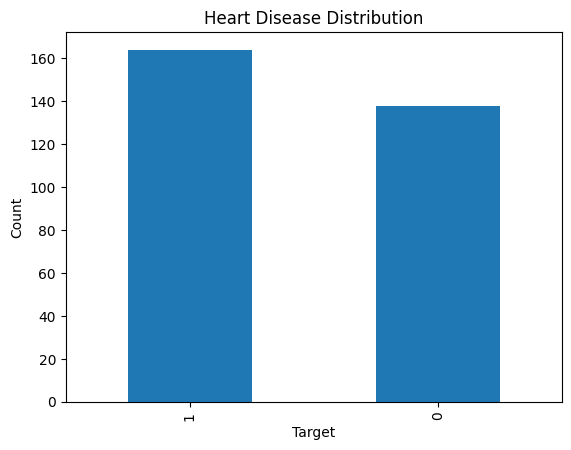

In [ ]:
import matplotlib.pyplot as plt

df["target"].value_counts().plot(kind="bar")

plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

In [ ]:
print(df.dtypes)

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [ ]:
numerical = df.select_dtypes(include="number")

numerical.describe().T

,count,mean,std,min,25%,50%,75%,max
age,302.0,54.420530,9.047970,29.0,48.00,55.5,61.00,77.0
sex,302.0,0.682119,0.466426,0.0,0.00,1.0,1.00,1.0
cp,302.0,0.963576,1.032044,0.0,0.00,1.0,2.00,3.0
trestbps,302.0,131.602649,17.563394,94.0,120.00,130.0,140.00,200.0
chol,302.0,246.500000,51.753489,126.0,211.00,240.5,274.75,564.0
fbs,302.0,0.149007,0.356686,0.0,0.00,0.0,0.00,1.0
restecg,302.0,0.526490,0.526027,0.0,0.00,1.0,1.00,2.0
thalach,302.0,149.569536,22.903527,71.0,133.25,152.5,166.00,202.0
exang,302.0,0.327815,0.470196,0.0,0.00,0.0,1.00,1.0
oldpeak,302.0,1.043046,1.161452,0.0,0.00,0.8,1.60,6.2


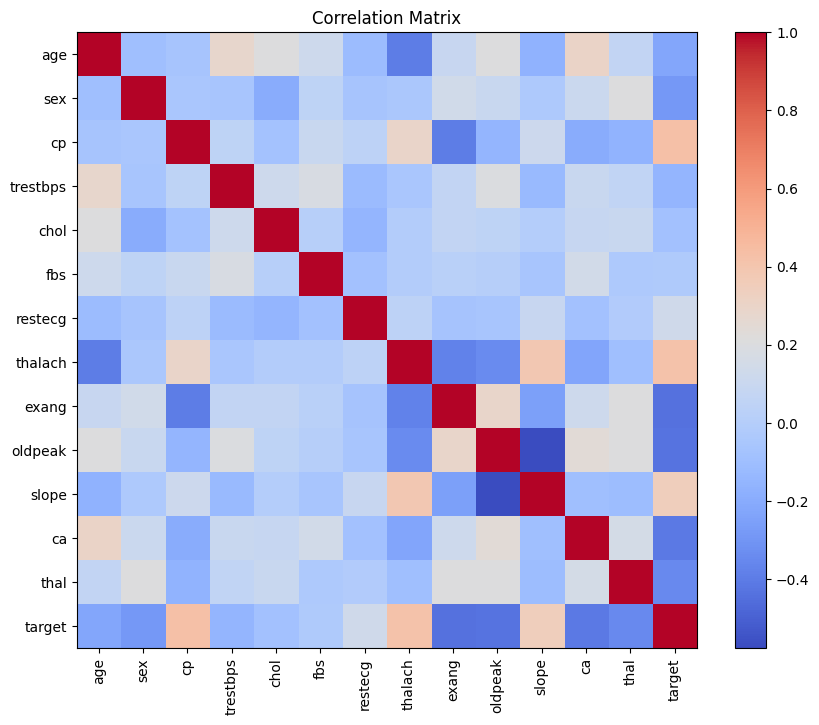

In [ ]:
import matplotlib.pyplot as plt

corr = df.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()

4B

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("gold/clean_data.csv")

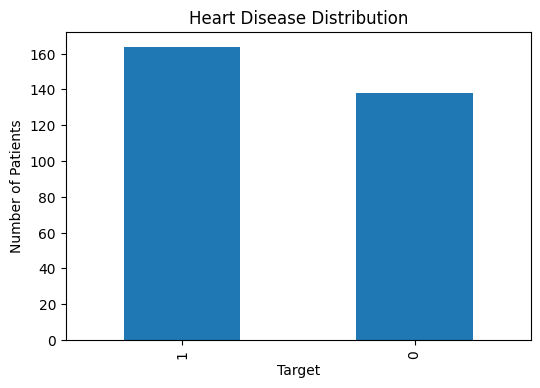

In [ ]:
plt.figure(figsize=(6,4))

df["target"].value_counts().plot(kind="bar")

plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Patients")

plt.show()

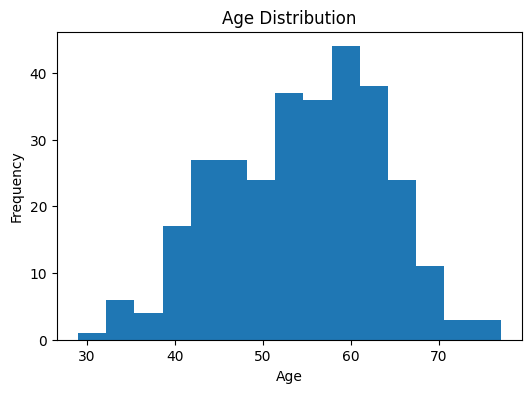

In [ ]:
plt.figure(figsize=(6,4))

plt.hist(df["age"], bins=15)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

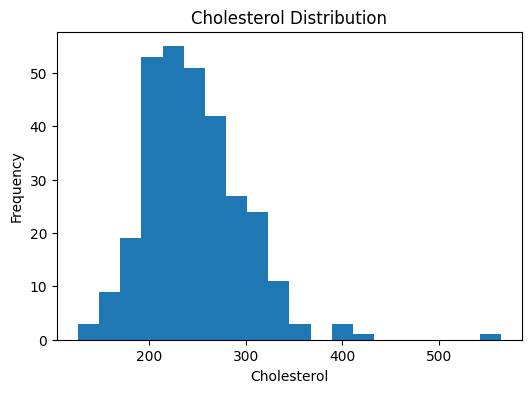

In [ ]:
plt.figure(figsize=(6,4))

plt.hist(df["chol"], bins=20)

plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Frequency")

plt.show()

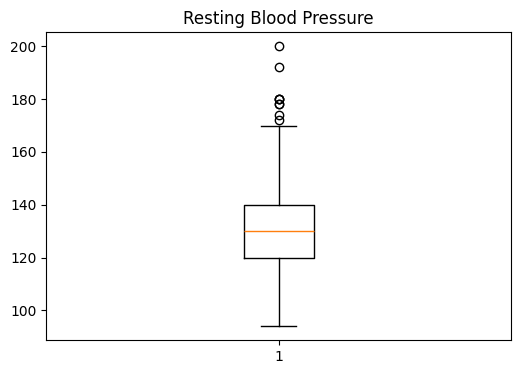

In [ ]:
plt.figure(figsize=(6,4))

plt.boxplot(df["trestbps"])

plt.title("Resting Blood Pressure")

plt.show()

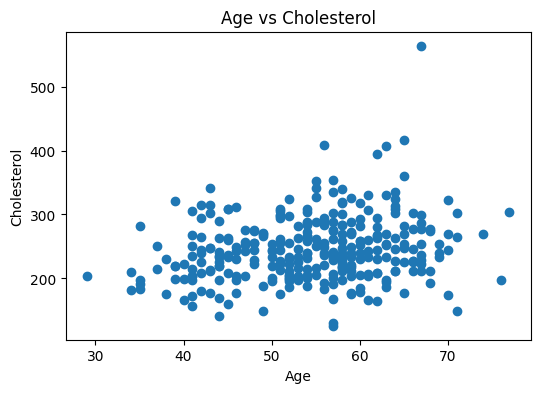

In [ ]:
plt.figure(figsize=(6,4))

plt.scatter(df["age"], df["chol"])

plt.title("Age vs Cholesterol")
plt.xlabel("Age")
plt.ylabel("Cholesterol")

plt.show()

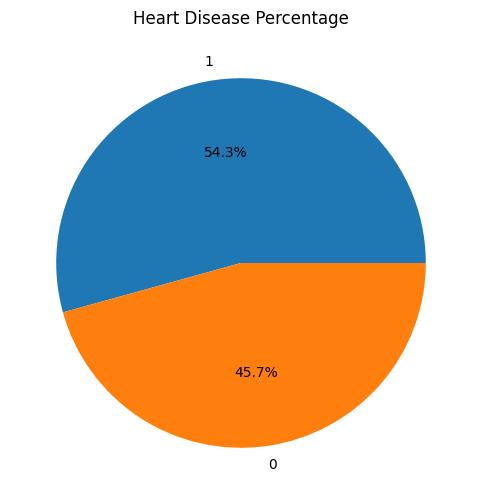

In [ ]:
plt.figure(figsize=(6,6))

df["target"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Heart Disease Percentage")
plt.ylabel("")

plt.show()

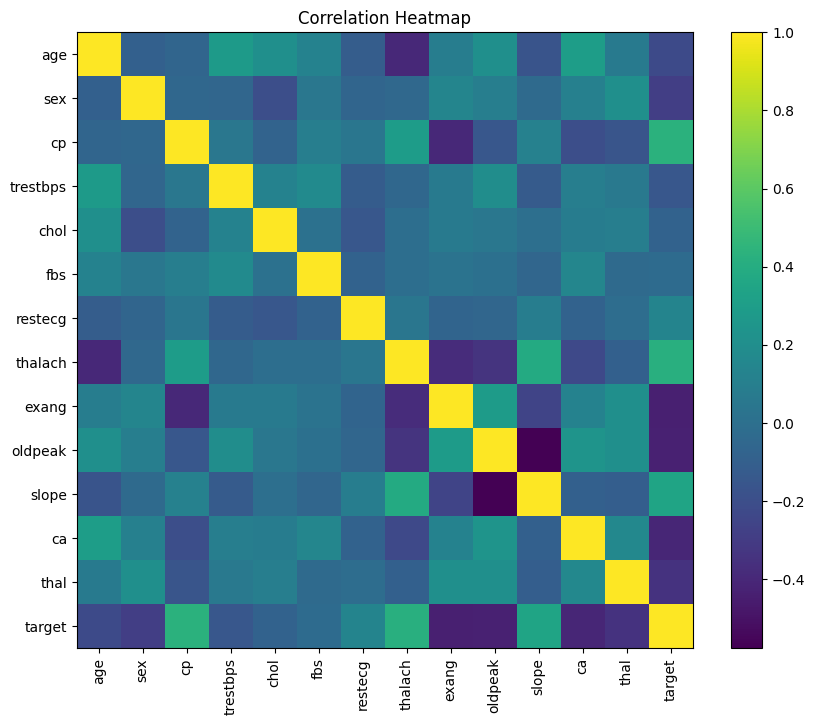

In [ ]:
import matplotlib.pyplot as plt

corr = df.corr()

plt.figure(figsize=(10,8))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.show()

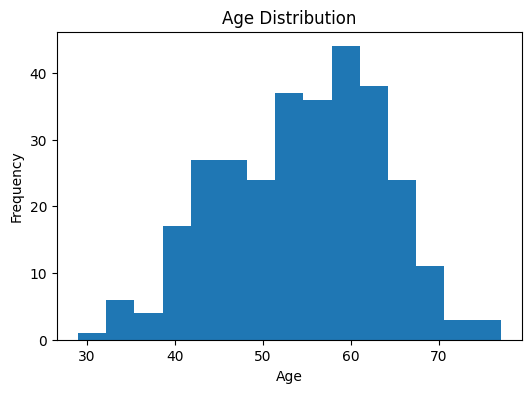

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df['age'], bins=15)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

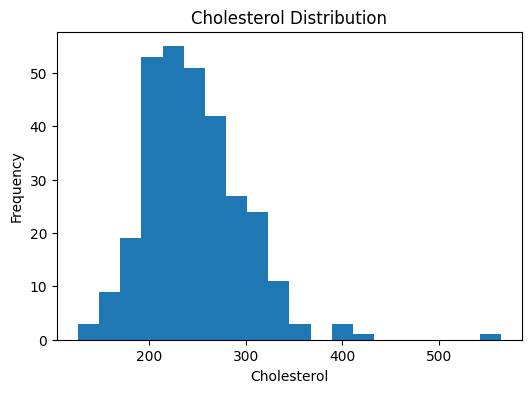

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df['chol'], bins=20)
plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Frequency")
plt.show()

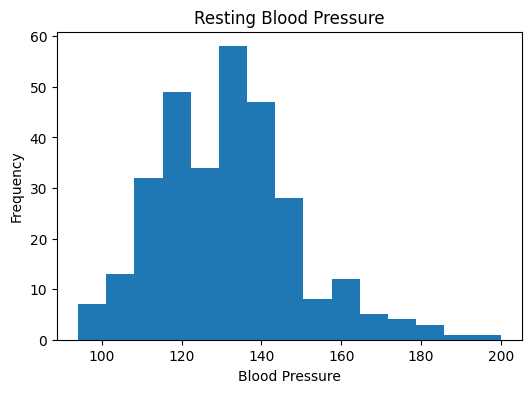

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df['trestbps'], bins=15)
plt.title("Resting Blood Pressure")
plt.xlabel("Blood Pressure")
plt.ylabel("Frequency")
plt.show()

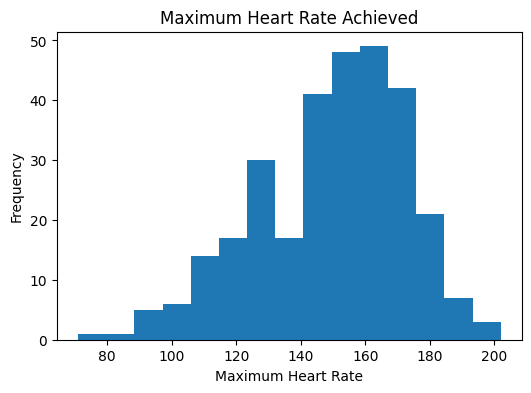

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df['thalach'], bins=15)
plt.title("Maximum Heart Rate Achieved")
plt.xlabel("Maximum Heart Rate")
plt.ylabel("Frequency")
plt.show()

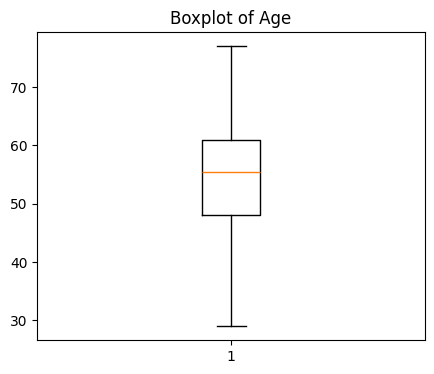

In [ ]:
plt.figure(figsize=(5,4))
plt.boxplot(df['age'])
plt.title("Boxplot of Age")
plt.show()

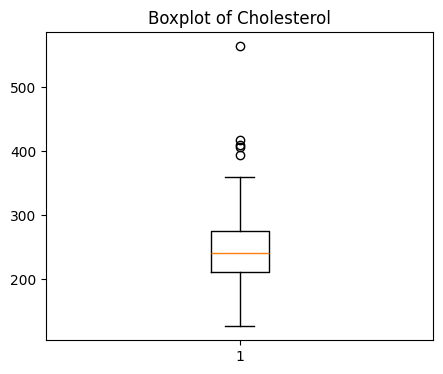

In [ ]:
plt.figure(figsize=(5,4))
plt.boxplot(df['chol'])
plt.title("Boxplot of Cholesterol")
plt.show()

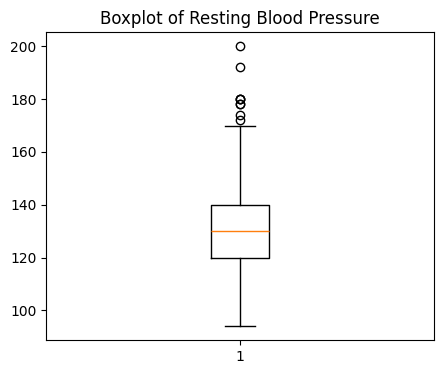

In [ ]:
plt.figure(figsize=(5,4))
plt.boxplot(df['trestbps'])
plt.title("Boxplot of Resting Blood Pressure")
plt.show()

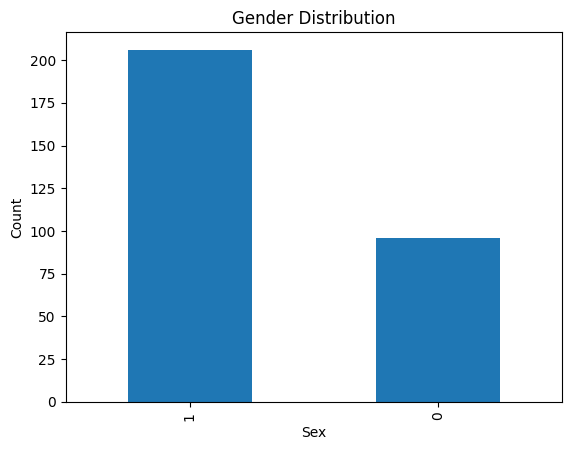

In [ ]:
df['sex'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

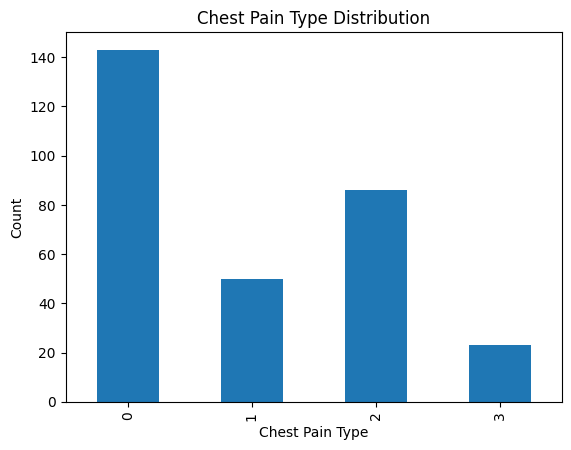

In [ ]:
df['cp'].value_counts().sort_index().plot(kind='bar')
plt.title("Chest Pain Type Distribution")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.show()

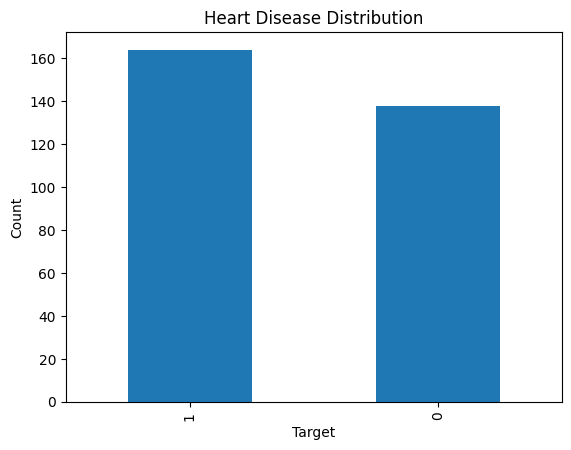

In [ ]:
df['target'].value_counts().plot(kind='bar')
plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

4c


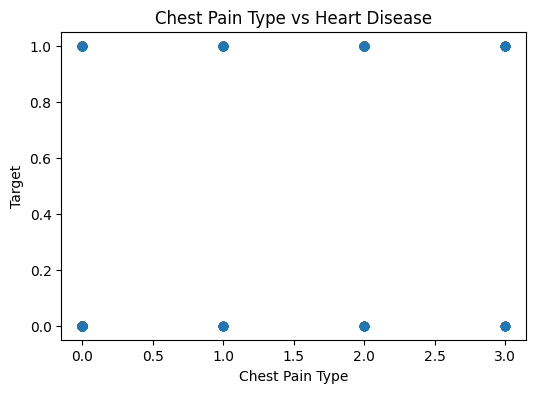

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(df["cp"], df["target"])
plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Target")
plt.show()

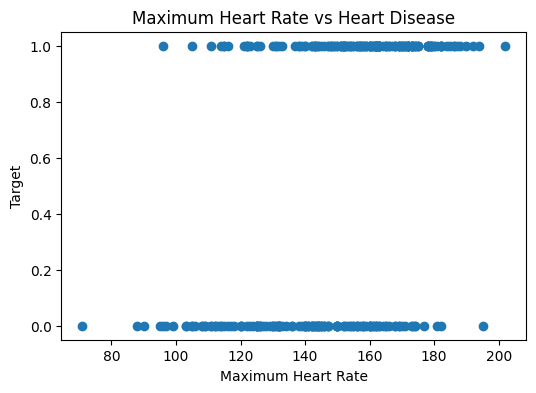

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df["thalach"], df["target"])
plt.title("Maximum Heart Rate vs Heart Disease")
plt.xlabel("Maximum Heart Rate")
plt.ylabel("Target")
plt.show()

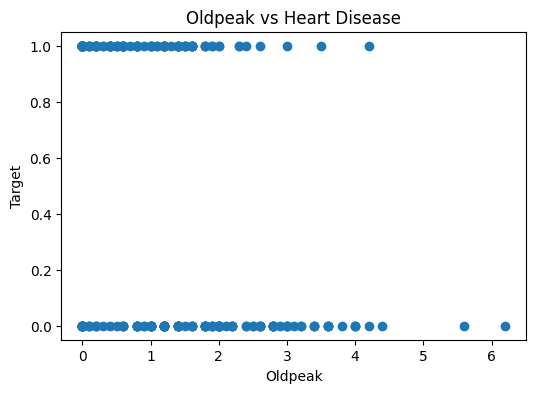

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df["oldpeak"], df["target"])
plt.title("Oldpeak vs Heart Disease")
plt.xlabel("Oldpeak")
plt.ylabel("Target")
plt.show()

<Figure size 600x400 with 0 Axes>

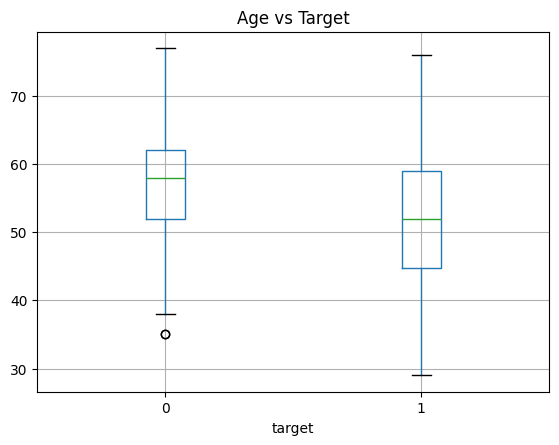

In [ ]:
plt.figure(figsize=(6,4))
df.boxplot(column="age", by="target")
plt.title("Age vs Target")
plt.suptitle("")
plt.show()

<Figure size 600x400 with 0 Axes>

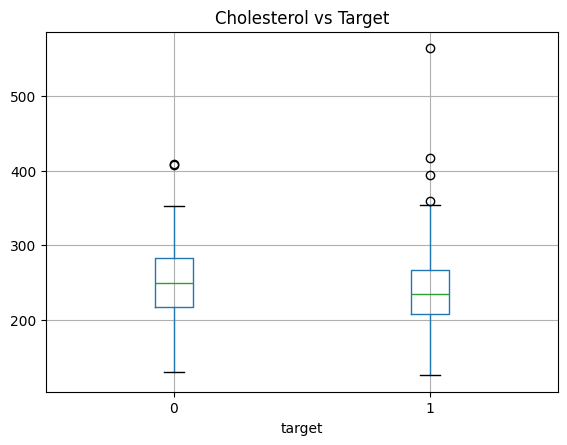

In [ ]:
plt.figure(figsize=(6,4))
df.boxplot(column="chol", by="target")
plt.title("Cholesterol vs Target")
plt.suptitle("")
plt.show()

<Figure size 600x400 with 0 Axes>

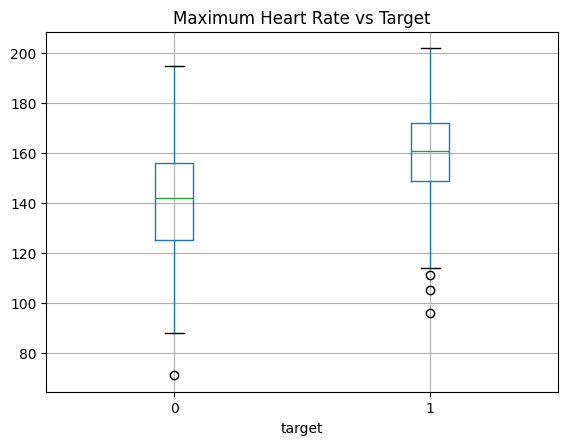

In [ ]:
plt.figure(figsize=(6,4))
df.boxplot(column="thalach", by="target")
plt.title("Maximum Heart Rate vs Target")
plt.suptitle("")
plt.show()

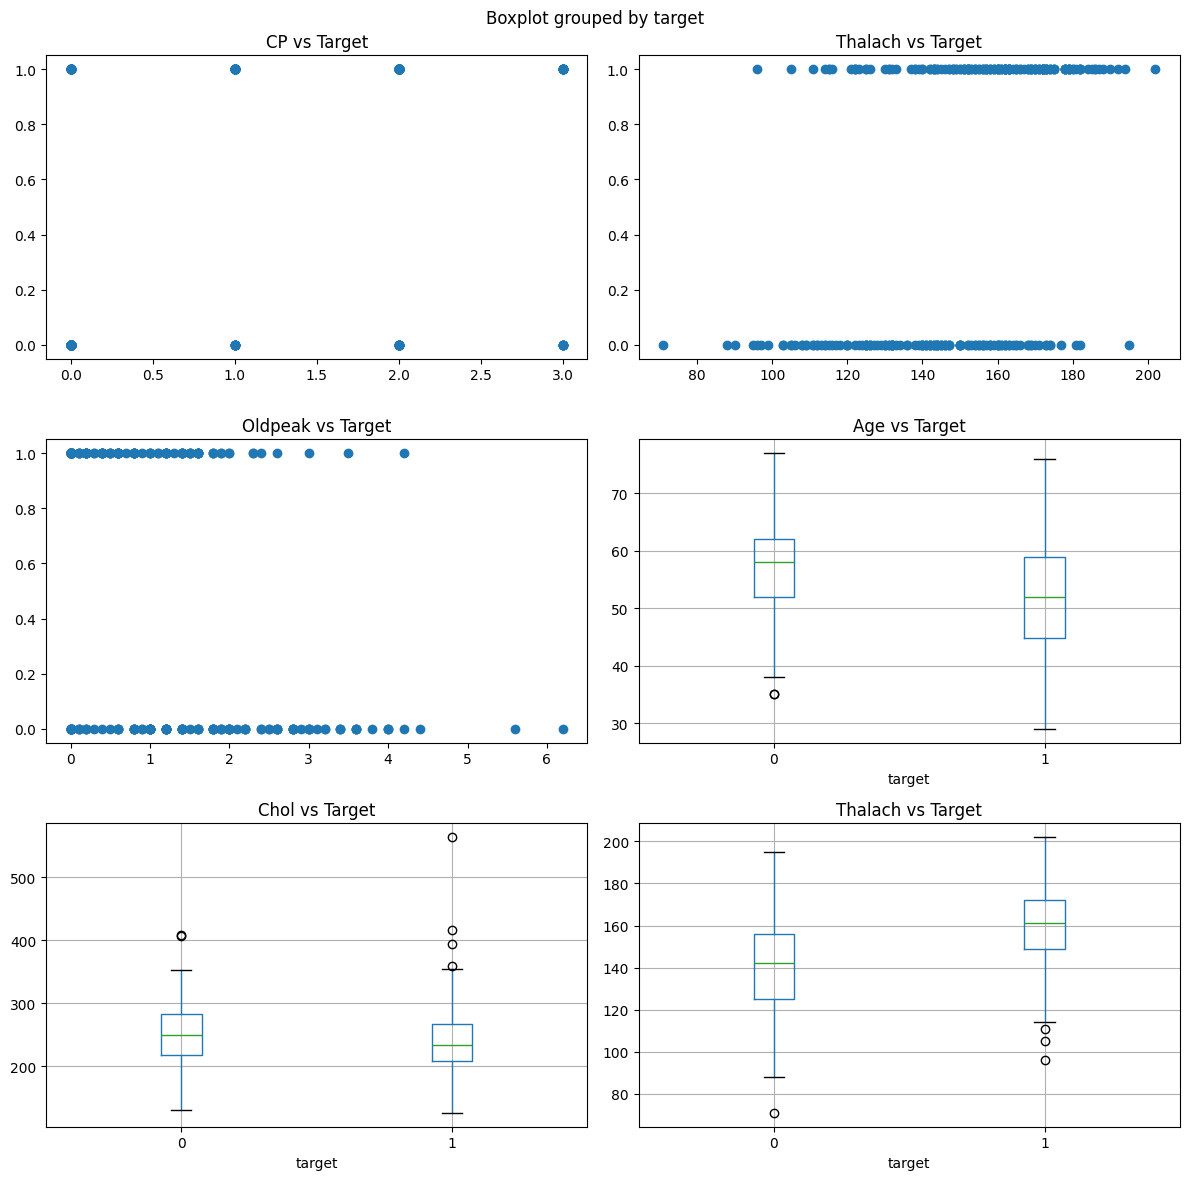

In [ ]:
fig, axes = plt.subplots(3,2, figsize=(12,12))

axes[0,0].scatter(df["cp"],df["target"])
axes[0,0].set_title("CP vs Target")

axes[0,1].scatter(df["thalach"],df["target"])
axes[0,1].set_title("Thalach vs Target")

axes[1,0].scatter(df["oldpeak"],df["target"])
axes[1,0].set_title("Oldpeak vs Target")

df.boxplot(column="age",by="target",ax=axes[1,1])
axes[1,1].set_title("Age vs Target")

df.boxplot(column="chol",by="target",ax=axes[2,0])
axes[2,0].set_title("Chol vs Target")

df.boxplot(column="thalach",by="target",ax=axes[2,1])
axes[2,1].set_title("Thalach vs Target")

plt.tight_layout()
plt.show()

4D

In [ ]:
import pandas as pd

df = pd.read_csv("gold/clean_data.csv")

In [ ]:
print(df.groupby("cp")["target"].mean())

cp
0    0.272727
1    0.820000
2    0.790698
3    0.695652
Name: target, dtype: float64


In [ ]:
print(df.groupby("exang")["target"].mean())

exang
0    0.694581
1    0.232323
Name: target, dtype: float64


In [ ]:
print(df.groupby("target")["thalach"].mean())

target
0    139.101449
1    158.378049
Name: thalach, dtype: float64


In [ ]:
print(df.groupby("target")["age"].mean())

target
0    56.601449
1    52.585366
Name: age, dtype: float64


### 5A

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
df = pd.read_csv("gold/clean_data.csv")

print(df.shape)
df.head()

(302, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
X = df.drop("target", axis=1)

y = df["target"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (302, 13)
Target: (302,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 241
Testing Samples: 61


In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
print("Logistic Regression")

print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred))

print("\nClassification Report")
print(classification_report(y_test, lr_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, lr_pred))

Logistic Regression
Accuracy: 0.7868852459016393
Precision: 0.7222222222222222
Recall: 0.896551724137931
F1 Score: 0.8

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.69      0.77        32
           1       0.72      0.90      0.80        29

    accuracy                           0.79        61
   macro avg       0.80      0.79      0.79        61
weighted avg       0.80      0.79      0.79        61


Confusion Matrix
[[22 10]
 [ 3 26]]


In [ ]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [ ]:
print("Decision Tree")

print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall:", recall_score(y_test, dt_pred))
print("F1 Score:", f1_score(y_test, dt_pred))

print("\nClassification Report")
print(classification_report(y_test, dt_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, dt_pred))

Decision Tree
Accuracy: 0.7377049180327869
Precision: 0.7407407407407407
Recall: 0.6896551724137931
F1 Score: 0.7142857142857143

Classification Report
              precision    recall  f1-score   support

           0       0.74      0.78      0.76        32
           1       0.74      0.69      0.71        29

    accuracy                           0.74        61
   macro avg       0.74      0.74      0.74        61
weighted avg       0.74      0.74      0.74        61


Confusion Matrix
[[25  7]
 [ 9 20]]


In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [ ]:
print("Random Forest")

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))

print("\nClassification Report")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_pred))

Random Forest
Accuracy: 0.8360655737704918
Precision: 0.7878787878787878
Recall: 0.896551724137931
F1 Score: 0.8387096774193549

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.78      0.83        32
           1       0.79      0.90      0.84        29

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61


Confusion Matrix
[[25  7]
 [ 3 26]]


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.786885   0.722222  0.896552  0.800000
1        Decision Tree  0.737705   0.740741  0.689655  0.714286
2        Random Forest  0.836066   0.787879  0.896552  0.838710


5B

In [ ]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

     Feature  Importance
7    thalach    0.138781
2         cp    0.131618
9    oldpeak    0.117095
12      thal    0.101598
11        ca    0.090493
0        age    0.090276
4       chol    0.075677
3   trestbps    0.071152
10     slope    0.055007
8      exang    0.050500
1        sex    0.038310
6    restecg    0.026865
5        fbs    0.012628


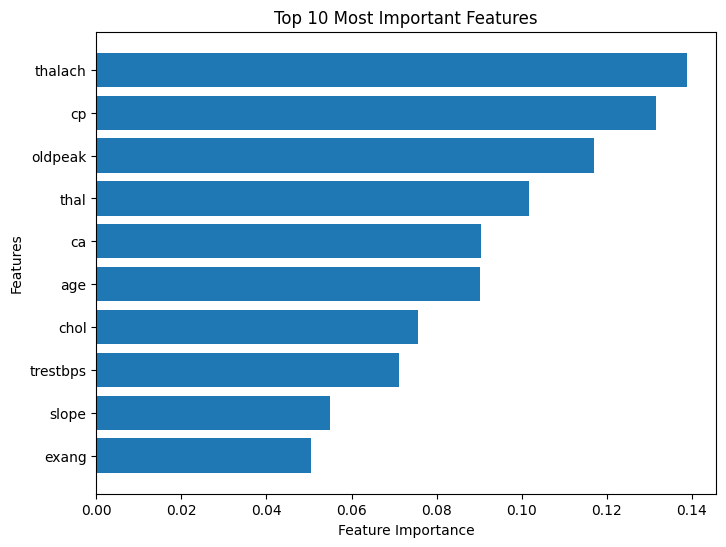

In [ ]:
import matplotlib.pyplot as plt

top10 = importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.title("Top 10 Most Important Features")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
low_importance = importance[
    importance["Importance"] < 0.01
]

print("Features with Importance < 0.01")
print(low_importance)

Features with Importance < 0.01
Empty DataFrame
Columns: [Feature, Importance]
Index: []


In [ ]:
print("="*50)
print("Most Important Features")
print("="*50)

print(importance.head(10))

print("\n")

print("="*50)
print("Features Suggested for Removal")
print("="*50)

print(low_importance)

Most Important Features
     Feature  Importance
7    thalach    0.138781
2         cp    0.131618
9    oldpeak    0.117095
12      thal    0.101598
11        ca    0.090493
0        age    0.090276
4       chol    0.075677
3   trestbps    0.071152
10     slope    0.055007
8      exang    0.050500


Features Suggested for Removal
Empty DataFrame
Columns: [Feature, Importance]
Index: []


In [ ]:
importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.


5c

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
base_models = [

    ('lr', LogisticRegression(max_iter=1000)),

    ('dt', DecisionTreeClassifier(random_state=42)),

    ('rf', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))

]

In [ ]:
meta_model = LogisticRegression(max_iter=1000)

In [ ]:
stack_model = StackingClassifier(

    estimators=base_models,

    final_estimator=meta_model,

    cv=5

)

stack_model.fit(X_train, y_train)

print("Stacking Model Trained Successfully")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Stacking Model Trained Successfully


In [ ]:
stack_pred = stack_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, stack_pred))
print("Precision:", precision_score(y_test, stack_pred))
print("Recall   :", recall_score(y_test, stack_pred))
print("F1 Score :", f1_score(y_test, stack_pred))

Accuracy : 0.8360655737704918
Precision: 0.7878787878787878
Recall   : 0.896551724137931
F1 Score : 0.8387096774193549


In [ ]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Stacking Classifier"
    ],

    "Accuracy":[
        accuracy_score(y_test, lr.predict(X_test)),
        accuracy_score(y_test, dt.predict(X_test)),
        accuracy_score(y_test, rf.predict(X_test)),
        accuracy_score(y_test, stack_pred)
    ],

    "Precision":[
        precision_score(y_test, lr.predict(X_test)),
        precision_score(y_test, dt.predict(X_test)),
        precision_score(y_test, rf.predict(X_test)),
        precision_score(y_test, stack_pred)
    ],

    "Recall":[
        recall_score(y_test, lr.predict(X_test)),
        recall_score(y_test, dt.predict(X_test)),
        recall_score(y_test, rf.predict(X_test)),
        recall_score(y_test, stack_pred)
    ],

    "F1 Score":[
        f1_score(y_test, lr.predict(X_test)),
        f1_score(y_test, dt.predict(X_test)),
        f1_score(y_test, rf.predict(X_test)),
        f1_score(y_test, stack_pred)
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.786885,0.722222,0.896552,0.800000
1,Decision Tree,0.737705,0.740741,0.689655,0.714286
2,Random Forest,0.836066,0.787879,0.896552,0.838710
3,Stacking Classifier,0.836066,0.787879,0.896552,0.838710


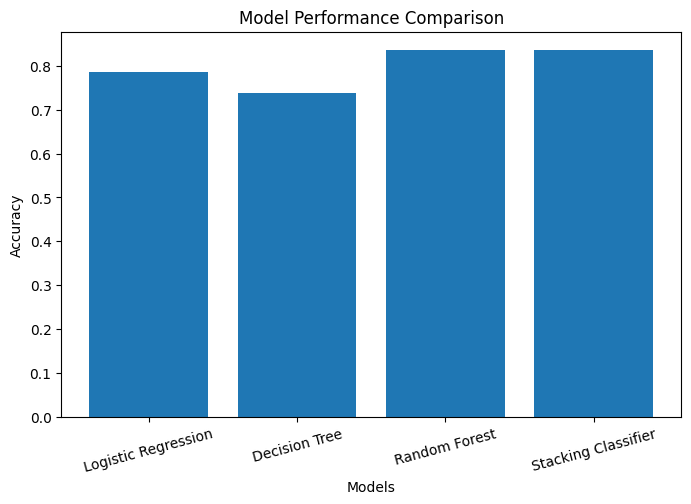

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Model Performance Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.show()

5d

In [ ]:
!pip install shap

In [ ]:
import shap
import matplotlib.pyplot as plt

In [ ]:
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

print("SHAP values generated successfully.")

SHAP values generated successfully.


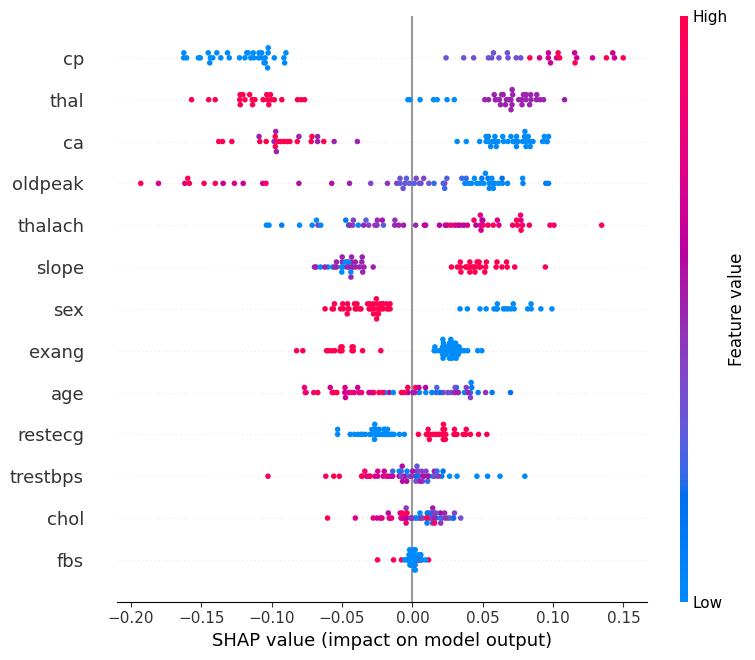

In [ ]:
# For binary classification use class 1
shap.summary_plot(
    shap_values[:, :, 1],
    X_test
)

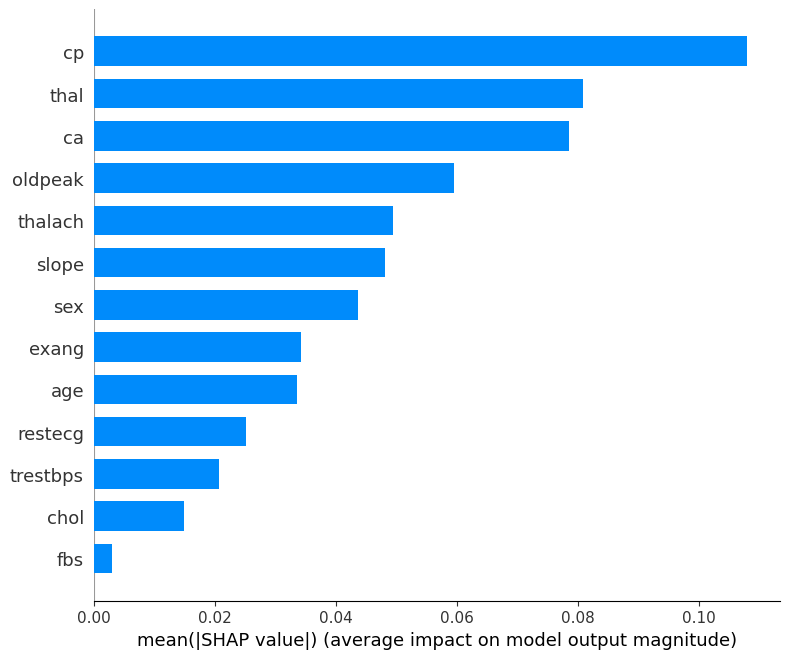

In [ ]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    plot_type="bar"
)

In [ ]:
shap.initjs()

shap.force_plot(
    explainer.expected_value[1],
    shap_values[0, :, 1],
    X_test.iloc[0]
)

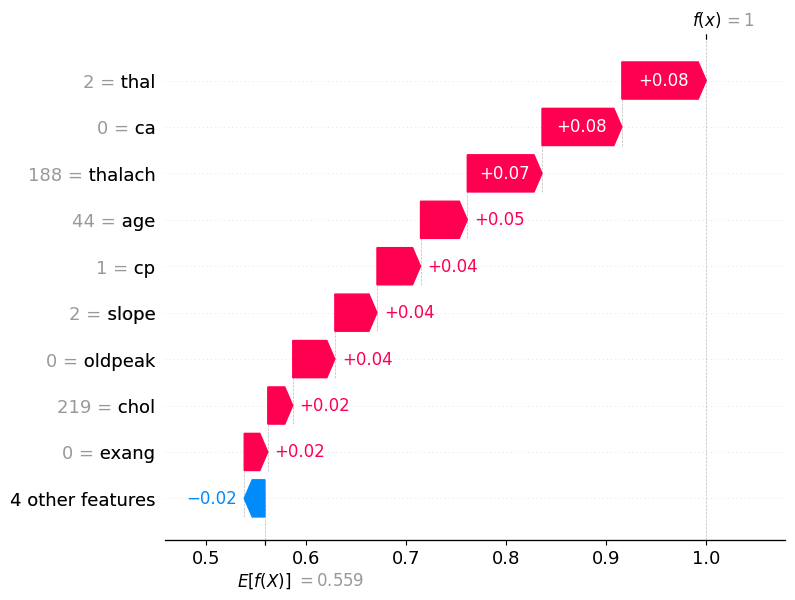

In [ ]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0, :, 1],
        base_values=explainer.expected_value[1],
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)

In [ ]:
import pandas as pd
import numpy as np

sample = 0

impact = pd.DataFrame({
    "Feature": X_test.columns,
    "SHAP Value": shap_values[sample, :, 1]
})

impact["Absolute"] = impact["SHAP Value"].abs()

impact = impact.sort_values(
    "Absolute",
    ascending=False
)

print(impact)

     Feature  SHAP Value  Absolute
12      thal    0.084307  0.084307
11        ca    0.079768  0.079768
7    thalach    0.074653  0.074653
0        age    0.046723  0.046723
2         cp    0.043530  0.043530
10     slope    0.042092  0.042092
9    oldpeak    0.042056  0.042056
4       chol    0.024931  0.024931
8      exang    0.023561  0.023561
6    restecg   -0.020279  0.020279
3   trestbps    0.015956  0.015956
1        sex   -0.015899  0.015899
5        fbs   -0.000485  0.000485


In [ ]:
positive = impact[impact["SHAP Value"] > 0]

print(positive.head())

    Feature  SHAP Value  Absolute
12     thal    0.084307  0.084307
11       ca    0.079768  0.079768
7   thalach    0.074653  0.074653
0       age    0.046723  0.046723
2        cp    0.043530  0.043530


In [ ]:
negative = impact[impact["SHAP Value"] < 0]

print(negative.head())

   Feature  SHAP Value  Absolute
6  restecg   -0.020279  0.020279
1      sex   -0.015899  0.015899
5      fbs   -0.000485  0.000485


5E

In [ ]:
from sklearn.metrics import accuracy_score

# Training predictions
train_pred = rf.predict(X_train)

# Testing predictions
test_pred = rf.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Training Accuracy :", round(train_acc,4))
print("Testing Accuracy  :", round(test_acc,4))
print("Overfitting Gap   :", round(train_acc-test_acc,4))

Training Accuracy : 1.0
Testing Accuracy  : 0.8361
Overfitting Gap   : 0.1639


In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores")
print(cv_scores)

print("\nMean Accuracy :", np.mean(cv_scores))
print("Standard Deviation :", np.std(cv_scores))


Cross Validation Scores
[0.83606557 0.81967213 0.9        0.8        0.78333333]

Mean Accuracy : 0.8278142076502732
Standard Deviation : 0.04024262764034185


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {

    "n_estimators":[50,100,200],

    "max_depth":[5,10,None],

    "min_samples_split":[2,5,10]

}

grid = GridSearchCV(

    estimator=RandomForestClassifier(random_state=42),

    param_grid=param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [ ]:
print("Best Parameters")
print(grid.best_params_)

print("\nBest Cross Validation Accuracy")
print(grid.best_score_)

Best Parameters
{'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 100}

Best Cross Validation Accuracy
0.8176020408163266


In [ ]:
best_rf = grid.best_estimator_

best_rf.fit(X_train,y_train)

best_prediction = best_rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

before = accuracy_score(
    y_test,
    rf.predict(X_test)
)

after = accuracy_score(
    y_test,
    best_prediction
)

print("Before Tuning :", before)
print("After Tuning :", after)

Before Tuning : 0.8360655737704918
After Tuning : 0.8360655737704918


In [ ]:
import pandas as pd

comparison = pd.DataFrame({

    "Model":[

        "Random Forest (Default)",

        "Random Forest (GridSearchCV)"

    ],

    "Accuracy":[

        before,

        after

    ]

})

comparison

,Model,Accuracy
0,Random Forest (Default),0.836066
1,Random Forest (GridSearchCV),0.836066


In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

metrics = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ],

    "Before Tuning":[

        accuracy_score(y_test,rf.predict(X_test)),

        precision_score(y_test,rf.predict(X_test)),

        recall_score(y_test,rf.predict(X_test)),

        f1_score(y_test,rf.predict(X_test))

    ],

    "After Tuning":[

        accuracy_score(y_test,best_prediction),

        precision_score(y_test,best_prediction),

        recall_score(y_test,best_prediction),

        f1_score(y_test,best_prediction)

    ]

})

metrics

,Metric,Before Tuning,After Tuning
0,Accuracy,0.836066,0.836066
1,Precision,0.787879,0.787879
2,Recall,0.896552,0.896552
3,F1 Score,0.838710,0.838710


6

In [ ]:
# Select one patient from the test set
sample = X_test.iloc[[0]]

# Predict
prediction = best_rf.predict(sample)

# Prediction probability
probability = best_rf.predict_proba(sample)

print("Prediction:", prediction[0])
print("Probability:", probability)

Prediction: 1
Probability: [[0.04047122 0.95952878]]


In [ ]:
print("Patient Details")
print(sample)

Patient Details
     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
179   44    1   1       130   219    0        0      188      0      0.0   

     slope  ca  thal  
179      2   0     2  


In [ ]:
if prediction[0] == 1:
    print("Prediction: The model predicts that the patient is likely to have heart disease.")
else:
    print("Prediction: The model predicts that the patient is unlikely to have heart disease.")

Prediction: The model predicts that the patient is likely to have heart disease.


In [ ]:
actual = y_test.iloc[0]

print("Actual Value   :", actual)
print("Predicted Value:", prediction[0])

if actual == prediction[0]:
    print("Prediction is Correct")
else:
    print("Prediction is Incorrect")

Actual Value   : 1
Predicted Value: 1
Prediction is Correct


In [ ]:
import pandas as pd

new_patient = pd.DataFrame({
    "age":[55],
    "sex":[1],
    "cp":[2],
    "trestbps":[130],
    "chol":[250],
    "fbs":[0],
    "restecg":[1],
    "thalach":[150],
    "exang":[0],
    "oldpeak":[1.2],
    "slope":[2],
    "ca":[0],
    "thal":[2]
})

prediction = best_rf.predict(new_patient)
probability = best_rf.predict_proba(new_patient)

print("Prediction:", prediction[0])
print("Probability:", probability)

if prediction[0] == 1:
    print("Result: Patient is likely to have Heart Disease.")
else:
    print("Result: Patient is unlikely to have Heart Disease.")

Prediction: 1
Probability: [[0.15918624 0.84081376]]
Result: Patient is likely to have Heart Disease.
